# WR weekly Silver facts

## tl;dr

This notebook creates `silver_wr_week` for the 2023–2025 contextual WR population at one row per `player_id + season + week + team`. The output contains **8,881 rows and 59 columns** across three season partitions.

The play-level facts contribute 31,779 targets, 342,831 target-linked air yards, 4,004 red-zone targets, 860 goal-line targets, and 2,612 end-zone targets. PBP target, air-yard, and rush-attempt totals reconcile exactly with the 7,823 WR rows that have weekly-stat evidence. Another 1,058 snap-only WR rows retain null weekly statistics while receiving observed zero PBP opportunity counts.

Calculated target share matches the nflverse weekly-stat value for all 7,823 comparable rows. `target_air_yards_share` intentionally uses air yards attached to identified targets, while nflverse `air_yards_share` uses team passing air yards; the two measures therefore differ on 4,626 comparable rows and are not treated as interchangeable.

All declared grain, relationship, denominator, null-versus-zero, reconciliation, and Parquet round-trip checks pass.

## Context & Methods

### Scope

The shared Silver notebooks established canonical player-week records, standardized plays, and team-week opportunity denominators. This notebook uses those foundations to create the first position-specific weekly fact table.

Weekly player statistics remain nullable source evidence. Standardized PBP supplies observed player opportunity counts, including zeroes for WRs who appeared in a covered game without a target or carry. Team-week facts supply the denominators for transparent same-week shares.

### Key assumptions

- A WR row is eligible when `player_week.is_wr_week` is true. This uses weekly stat or snap position evidence rather than the player master's latest position.
- Weekly stats remain authoritative for receiving and rushing production. PBP counts are retained separately and reconciled before use as opportunity numerators.
- `target_share` uses PBP targets divided by team targets.
- `target_air_yards_share` uses PBP air yards attached to identified targets divided by team target-linked air yards.
- nflverse `air_yards_share` uses team passing air yards instead. It is validation evidence, not the definition adopted for `target_air_yards_share`.
- A zero team denominator produces a null share. A valid denominator with no player opportunity produces a zero share.
- Every calculation is same-week. No rolling, season-to-date, ranking, or future-looking feature is created here.

## Data

### 1. Set up paths, grains, and selected fields

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEASONS = [2023, 2024, 2025]
WR_WEEK_GRAIN = ["player_id", "season", "week", "team"]
PLAYER_GAME_TEAM_KEY = ["player_id", "game_id", "team"]
TEAM_WEEK_GRAIN = ["team", "season", "week"]

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

BRONZE_DIR = PROJECT_ROOT / "data/bronze"
SILVER_DIR = PROJECT_ROOT / "data/silver"
PLAYER_WEEK_DIR = SILVER_DIR / "player_week"
STANDARDIZED_PLAYS_DIR = SILVER_DIR / "standardized_plays"
TEAM_WEEK_OPPORTUNITY_DIR = SILVER_DIR / "team_week_opportunity"
WR_WEEK_DIR = SILVER_DIR / "wr_week"

PLAYER_WEEK_COLUMNS = [
    "player_id",
    "game_id",
    "season",
    "week",
    "game_type",
    "season_type",
    "team",
    "opponent_team",
    "display_name",
    "stats_position",
    "snap_position",
    "has_stat_record",
    "has_snap_record",
    "participated_game",
    "offensive_participant",
    "offense_snaps",
    "offense_snap_pct",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "receiving_targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
]

PBP_COLUMNS = [
    "game_id",
    "team",
    "receiver_player_id",
    "rusher_player_id",
    "target_air_yards",
    "is_target",
    "is_red_zone_target",
    "is_goal_line_target",
    "is_end_zone_target",
    "is_rush_attempt",
    "is_non_kneel_rush_attempt",
    "is_designed_rush_attempt",
    "is_red_zone_rush_attempt",
    "is_goal_line_rush_attempt",
]

TEAM_WEEK_COLUMNS = [
    "team",
    "season",
    "week",
    "game_id",
    "team_targets",
    "team_air_yards",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_non_kneel_rush_attempts",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

BRONZE_VALIDATION_COLUMNS = [
    "player_id",
    "season",
    "week",
    "team",
    "targets",
    "receiving_air_yards",
    "passing_air_yards",
    "target_share",
    "air_yards_share",
]

pd.set_option("display.max_columns", 70)

### 2. Define the WR metric contract

The output keeps weekly-stat production separate from PBP opportunity evidence. This preserves the shared null contract while allowing confirmed zero opportunities and denominator-based shares.

In [2]:
metric_contract = pd.DataFrame(
    [
        ["pbp_targets", "Count of canonical targets to the player", "standardized plays"],
        ["pbp_target_air_yards", "Air yards attached to canonical player targets", "standardized plays"],
        ["red_zone_targets", "Canonical targets at yardline_100 <= 20", "standardized plays"],
        ["goal_line_targets", "Canonical targets at yardline_100 <= 5", "standardized plays"],
        ["end_zone_targets", "Targets whose air yards reach the goal line", "standardized plays"],
        ["pbp_non_kneel_rush_attempts", "Canonical rush attempts excluding kneels", "standardized plays"],
        ["target_share", "pbp_targets / team_targets", "same-week team denominator"],
        ["target_air_yards_share", "pbp_target_air_yards / team_air_yards", "target-linked team denominator"],
        ["red_zone_target_share", "red_zone_targets / team_red_zone_targets", "same-week team denominator"],
        ["goal_line_target_share", "goal_line_targets / team_goal_line_targets", "same-week team denominator"],
        ["end_zone_target_share", "end_zone_targets / team_end_zone_targets", "same-week team denominator"],
        ["rush_attempt_share", "pbp_non_kneel_rush_attempts / team_non_kneel_rush_attempts", "same-week team denominator"],
    ],
    columns=["field", "definition", "source_or_denominator"],
)

metric_contract

,field,definition,source_or_denominator
0,pbp_targets,Count of canonical targets to the player,standardized plays
1,pbp_target_air_yards,Air yards attached to canonical player targets,standardized plays
2,red_zone_targets,Canonical targets at yardline_100 <= 20,standardized plays
3,goal_line_targets,Canonical targets at yardline_100 <= 5,standardized plays
4,end_zone_targets,Targets whose air yards reach the goal line,standardized plays
5,pbp_non_kneel_rush_attempts,Canonical rush attempts excluding kneels,standardized plays
6,target_share,pbp_targets / team_targets,same-week team denominator
7,target_air_yards_share,pbp_target_air_yards / team_air_yards,target-linked team denominator
8,red_zone_target_share,red_zone_targets / team_red_zone_targets,same-week team denominator
9,goal_line_target_share,goal_line_targets / team_goal_line_targets,same-week team denominator


### 3. Load the persisted inputs

In [3]:
player_week_paths = sorted(PLAYER_WEEK_DIR.glob("*.parquet"))
standardized_play_paths = sorted(STANDARDIZED_PLAYS_DIR.glob("*.parquet"))
team_week_paths = sorted(TEAM_WEEK_OPPORTUNITY_DIR.glob("*.parquet"))
bronze_stat_paths = sorted((BRONZE_DIR / "player_stats_weekly").glob("*.parquet"))

assert len(player_week_paths) == len(SEASONS)
assert len(standardized_play_paths) == len(SEASONS)
assert len(team_week_paths) == len(SEASONS)
assert len(bronze_stat_paths) == len(SEASONS)

player_week = pd.concat(
    [pd.read_parquet(path) for path in player_week_paths],
    ignore_index=True,
)
standardized_plays = pd.concat(
    [pd.read_parquet(path, columns=PBP_COLUMNS) for path in standardized_play_paths],
    ignore_index=True,
)
team_week_opportunity = pd.concat(
    [pd.read_parquet(path, columns=TEAM_WEEK_COLUMNS) for path in team_week_paths],
    ignore_index=True,
)
bronze_weekly_stats = pd.concat(
    [pd.read_parquet(path, columns=BRONZE_VALIDATION_COLUMNS) for path in bronze_stat_paths],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [
        ["Silver player_week", len(player_week), len(player_week.columns), len(PLAYER_WEEK_COLUMNS)],
        ["Silver standardized_plays", len(standardized_plays), 56, len(standardized_plays.columns)],
        ["Silver team_week_opportunity", len(team_week_opportunity), 24, len(team_week_opportunity.columns)],
        ["Bronze weekly stats (validation only)", len(bronze_weekly_stats), 150, len(bronze_weekly_stats.columns)],
    ],
    columns=["input", "rows", "columns_available", "columns_loaded_or_selected"],
)

input_summary

,input,rows,columns_available,columns_loaded_or_selected
0,Silver player_week,79708,54,33
1,Silver standardized_plays,147928,56,14
2,Silver team_week_opportunity,1710,24,12
3,Bronze weekly stats (validation only),57048,150,9


## Results

### 4. Validate input grains and relationships

In [4]:
assert set(player_week["season"].unique()) == set(SEASONS)
assert set(team_week_opportunity["season"].unique()) == set(SEASONS)

assert player_week[WR_WEEK_GRAIN].notna().all().all()
assert not player_week.duplicated(WR_WEEK_GRAIN).any()
assert team_week_opportunity[TEAM_WEEK_GRAIN].notna().all().all()
assert not team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).any()

input_grain_summary = pd.DataFrame(
    [
        ["player_week", " + ".join(WR_WEEK_GRAIN), len(player_week), player_week.duplicated(WR_WEEK_GRAIN).sum()],
        ["team_week_opportunity", " + ".join(TEAM_WEEK_GRAIN), len(team_week_opportunity), team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).sum()],
    ],
    columns=["input", "declared_grain", "rows", "duplicate_grain_rows"],
)

input_grain_summary

,input,declared_grain,rows,duplicate_grain_rows
0,player_week,player_id + season + week + team,79708,0
1,team_week_opportunity,team + season + week,1710,0


### 5. Establish the contextual WR population

`is_wr_week` is already based on weekly stat or snap position evidence. Filtering it preserves stat-and-snap, snap-only, and stats-only observations without introducing roster-only rows.

In [5]:
wr_base = (
    player_week.loc[player_week["is_wr_week"], PLAYER_WEEK_COLUMNS]
    .sort_values(["season", "week", "team", "player_id"])
    .reset_index(drop=True)
)

assert wr_base[WR_WEEK_GRAIN].notna().all().all()
assert not wr_base.duplicated(WR_WEEK_GRAIN).any()

wr_population_summary = (
    wr_base.groupby(["season", "has_stat_record", "has_snap_record"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
)

print(f"Contextual WR player-weeks: {len(wr_base):,}")
wr_population_summary

Contextual WR player-weeks: 8,881


,season,has_stat_record,has_snap_record,rows
0,2023,False,True,401
1,2023,True,True,2600
2,2024,False,True,358
3,2024,True,False,2
4,2024,True,True,2574
5,2025,False,True,299
6,2025,True,False,8
7,2025,True,True,2639


### 6. Aggregate player opportunity from standardized plays

Receiver and rusher observations are aggregated independently at player-game-team grain. These PBP counts remain distinct from nullable weekly-stat columns so their agreement can be tested explicitly.

In [6]:
receiver_opportunity = (
    standardized_plays.loc[standardized_plays["receiver_player_id"].notna()]
    .groupby(["receiver_player_id", "game_id", "team"], dropna=False)
    .agg(
        pbp_targets=("is_target", "sum"),
        pbp_target_air_yards=("target_air_yards", "sum"),
        red_zone_targets=("is_red_zone_target", "sum"),
        goal_line_targets=("is_goal_line_target", "sum"),
        end_zone_targets=("is_end_zone_target", "sum"),
    )
    .reset_index()
    .rename(columns={"receiver_player_id": "player_id"})
)

rusher_opportunity = (
    standardized_plays.loc[standardized_plays["rusher_player_id"].notna()]
    .groupby(["rusher_player_id", "game_id", "team"], dropna=False)
    .agg(
        pbp_rush_attempts=("is_rush_attempt", "sum"),
        pbp_non_kneel_rush_attempts=("is_non_kneel_rush_attempt", "sum"),
        pbp_designed_rush_attempts=("is_designed_rush_attempt", "sum"),
        red_zone_rush_attempts=("is_red_zone_rush_attempt", "sum"),
        goal_line_rush_attempts=("is_goal_line_rush_attempt", "sum"),
    )
    .reset_index()
    .rename(columns={"rusher_player_id": "player_id"})
)

assert not receiver_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()
assert not rusher_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()

pd.DataFrame(
    [
        ["receiver opportunity", len(receiver_opportunity), len(receiver_opportunity.columns)],
        ["rusher opportunity", len(rusher_opportunity), len(rusher_opportunity.columns)],
    ],
    columns=["intermediate", "rows", "columns"],
)

,intermediate,rows,columns
0,receiver opportunity,13600,8
1,rusher opportunity,7102,8


In [7]:
wr_with_opportunity = (
    wr_base.merge(
        receiver_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
    .merge(
        rusher_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
)

PBP_COUNT_COLUMNS = [
    "pbp_targets",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "pbp_rush_attempts",
    "pbp_non_kneel_rush_attempts",
    "pbp_designed_rush_attempts",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
]

# Complete game-level PBP makes a missing player aggregate an observed zero opportunity.
for column in PBP_COUNT_COLUMNS:
    wr_with_opportunity[column] = (
        wr_with_opportunity[column].fillna(0).astype("Int64")
    )

wr_with_opportunity["pbp_target_air_yards"] = (
    wr_with_opportunity["pbp_target_air_yards"].fillna(0.0).astype("Float64")
)

assert len(wr_with_opportunity) == len(wr_base)
wr_with_opportunity[PBP_COUNT_COLUMNS + ["pbp_target_air_yards"]].sum()

pbp_targets                     31779.0
red_zone_targets                 4004.0
goal_line_targets                 860.0
end_zone_targets                 2612.0
pbp_rush_attempts                1338.0
pbp_non_kneel_rush_attempts      1338.0
pbp_designed_rush_attempts       1331.0
red_zone_rush_attempts            240.0
goal_line_rush_attempts            29.0
pbp_target_air_yards           342831.0
dtype: Float64

### 7. Reconcile PBP opportunity with weekly-stat evidence

In [8]:
stat_wr_rows = wr_with_opportunity["has_stat_record"]

opportunity_reconciliation = pd.DataFrame(
    [
        [
            "targets",
            int(wr_with_opportunity.loc[stat_wr_rows, "receiving_targets"].sum()),
            int(wr_with_opportunity.loc[stat_wr_rows, "pbp_targets"].sum()),
            int(
                wr_with_opportunity.loc[stat_wr_rows, "receiving_targets"]
                .astype("float64")
                .ne(wr_with_opportunity.loc[stat_wr_rows, "pbp_targets"].astype("float64"))
                .sum()
            ),
        ],
        [
            "receiving air yards",
            float(wr_with_opportunity.loc[stat_wr_rows, "receiving_air_yards"].sum()),
            float(wr_with_opportunity.loc[stat_wr_rows, "pbp_target_air_yards"].sum()),
            int(
                wr_with_opportunity.loc[stat_wr_rows, "receiving_air_yards"]
                .astype("float64")
                .ne(wr_with_opportunity.loc[stat_wr_rows, "pbp_target_air_yards"].astype("float64"))
                .sum()
            ),
        ],
        [
            "rush attempts",
            int(wr_with_opportunity.loc[stat_wr_rows, "rushing_attempts"].sum()),
            int(wr_with_opportunity.loc[stat_wr_rows, "pbp_rush_attempts"].sum()),
            int(
                wr_with_opportunity.loc[stat_wr_rows, "rushing_attempts"]
                .astype("float64")
                .ne(wr_with_opportunity.loc[stat_wr_rows, "pbp_rush_attempts"].astype("float64"))
                .sum()
            ),
        ],
    ],
    columns=["metric", "weekly_stat_total", "pbp_total", "player_week_differences"],
)
opportunity_reconciliation["total_difference"] = (
    opportunity_reconciliation["pbp_total"]
    - opportunity_reconciliation["weekly_stat_total"]
)

assert opportunity_reconciliation["player_week_differences"].eq(0).all()
assert opportunity_reconciliation["total_difference"].eq(0).all()

opportunity_reconciliation

,metric,weekly_stat_total,pbp_total,player_week_differences,total_difference
0,targets,31779.0,31779.0,0,0.0
1,receiving air yards,342831.0,342831.0,0,0.0
2,rush attempts,1338.0,1338.0,0,0.0


### 8. Add team-week opportunity denominators

Every WR observation must match one team-week row. The retained `game_id` values are checked before the duplicate team-side key is removed.

In [9]:
wr_with_team = wr_with_opportunity.merge(
    team_week_opportunity,
    on=TEAM_WEEK_GRAIN,
    how="left",
    validate="many_to_one",
    suffixes=("", "_team"),
    indicator="team_week_join",
)

assert len(wr_with_team) == len(wr_with_opportunity)
assert wr_with_team["team_week_join"].eq("both").all()
assert wr_with_team["game_id"].eq(wr_with_team["game_id_team"]).all()

wr_with_team = wr_with_team.drop(columns=["game_id_team", "team_week_join"])

pd.DataFrame(
    {
        "check": [
            "WR observations",
            "team-week matches",
            "game_id disagreements",
        ],
        "rows": [len(wr_with_team), len(wr_with_team), 0],
    }
)

,check,rows
0,WR observations,8881
1,team-week matches,8881
2,game_id disagreements,0


### 9. Calculate transparent WR opportunity shares

A share is null only when its team denominator is zero. Air-yard shares are signed ratios: negative player air yards can produce a negative value, and negative air yards elsewhere on the team can allow a player's share to exceed one.

In [10]:
SHARE_DEFINITIONS = {
    "target_share": ("pbp_targets", "team_targets"),
    "target_air_yards_share": ("pbp_target_air_yards", "team_air_yards"),
    "red_zone_target_share": ("red_zone_targets", "team_red_zone_targets"),
    "goal_line_target_share": ("goal_line_targets", "team_goal_line_targets"),
    "end_zone_target_share": ("end_zone_targets", "team_end_zone_targets"),
    "rush_attempt_share": (
        "pbp_non_kneel_rush_attempts",
        "team_non_kneel_rush_attempts",
    ),
    "red_zone_rush_share": (
        "red_zone_rush_attempts",
        "team_red_zone_rush_attempts",
    ),
    "goal_line_rush_share": (
        "goal_line_rush_attempts",
        "team_goal_line_rush_attempts",
    ),
}

for share_column, (numerator_column, denominator_column) in SHARE_DEFINITIONS.items():
    valid_denominator = wr_with_team[denominator_column].ne(0)
    wr_with_team[share_column] = (
        wr_with_team[numerator_column]
        .div(wr_with_team[denominator_column].where(valid_denominator))
        .astype("Float64")
    )
    assert wr_with_team.loc[~valid_denominator, share_column].isna().all()

bounded_share_columns = [
    "target_share",
    "red_zone_target_share",
    "goal_line_target_share",
    "end_zone_target_share",
    "rush_attempt_share",
    "red_zone_rush_share",
    "goal_line_rush_share",
]

for column in bounded_share_columns:
    assert wr_with_team[column].dropna().between(0, 1, inclusive="both").all()

assert np.isfinite(
    wr_with_team["target_air_yards_share"].dropna().astype("float64")
).all()

share_behavior_summary = pd.DataFrame(
    [
        {
            "share": share_column,
            "non_null_rows": wr_with_team[share_column].notna().sum(),
            "zero_denominator_rows": wr_with_team[denominator_column].eq(0).sum(),
            "minimum": wr_with_team[share_column].min(),
            "maximum": wr_with_team[share_column].max(),
        }
        for share_column, (_, denominator_column) in SHARE_DEFINITIONS.items()
    ]
)

share_behavior_summary

,share,non_null_rows,zero_denominator_rows,minimum,maximum
0,target_share,8881,0,0.000000,0.666667
1,target_air_yards_share,8881,0,-0.423077,1.441176
2,red_zone_target_share,8317,564,0.000000,1.000000
3,goal_line_target_share,4532,4349,0.000000,1.000000
4,end_zone_target_share,7473,1408,0.000000,1.000000
5,rush_attempt_share,8881,0,0.000000,0.277778
6,red_zone_rush_share,8253,628,0.000000,1.000000
7,goal_line_rush_share,5601,3280,0.000000,1.000000


### 10. Create `silver_wr_week`

In [11]:
PBP_OPPORTUNITY_COLUMNS = [
    "pbp_targets",
    "pbp_target_air_yards",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "pbp_rush_attempts",
    "pbp_non_kneel_rush_attempts",
    "pbp_designed_rush_attempts",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
]

TEAM_DENOMINATOR_COLUMNS = [
    column
    for column in TEAM_WEEK_COLUMNS
    if column not in ["team", "season", "week", "game_id"]
]

WR_WEEK_COLUMNS = [
    *PLAYER_WEEK_COLUMNS,
    *PBP_OPPORTUNITY_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
    *SHARE_DEFINITIONS.keys(),
]

silver_wr_week = (
    wr_with_team[WR_WEEK_COLUMNS]
    .sort_values(["season", "week", "team", "player_id"])
    .reset_index(drop=True)
)

assert len(silver_wr_week.columns) == len(set(silver_wr_week.columns))
assert silver_wr_week[WR_WEEK_GRAIN].notna().all().all()
assert not silver_wr_week.duplicated(WR_WEEK_GRAIN).any()
assert silver_wr_week.groupby(WR_WEEK_GRAIN)["game_id"].nunique().le(1).all()

pd.DataFrame(
    {
        "dataset": ["silver_wr_week"],
        "rows": [len(silver_wr_week)],
        "columns": [len(silver_wr_week.columns)],
        "grain": [" + ".join(WR_WEEK_GRAIN)],
        "duplicate_grain_rows": [silver_wr_week.duplicated(WR_WEEK_GRAIN).sum()],
        "null_grain_rows": [silver_wr_week[WR_WEEK_GRAIN].isna().any(axis=1).sum()],
    }
)

,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,silver_wr_week,8881,59,player_id + season + week + team,0,0


### 11. Validate missing statistics versus observed zero opportunity

In [12]:
snap_only_wr = silver_wr_week.loc[
    ~silver_wr_week["has_stat_record"] & silver_wr_week["has_snap_record"]
]
stats_only_wr = silver_wr_week.loc[
    silver_wr_week["has_stat_record"] & ~silver_wr_week["has_snap_record"]
]

assert snap_only_wr["receiving_targets"].isna().all()
assert snap_only_wr["rushing_attempts"].isna().all()
assert snap_only_wr["pbp_targets"].eq(0).all()
assert snap_only_wr["pbp_rush_attempts"].eq(0).all()
assert snap_only_wr["target_share"].eq(0).all()
assert stats_only_wr["participated_game"].isna().all()

null_zero_summary = pd.DataFrame(
    [
        [
            "snap-only WR rows",
            len(snap_only_wr),
            snap_only_wr["receiving_targets"].isna().sum(),
            snap_only_wr["pbp_targets"].eq(0).sum(),
            snap_only_wr["target_share"].eq(0).sum(),
        ],
        [
            "stats-only WR rows",
            len(stats_only_wr),
            stats_only_wr["receiving_targets"].isna().sum(),
            stats_only_wr["pbp_targets"].eq(0).sum(),
            stats_only_wr["target_share"].eq(0).sum(),
        ],
    ],
    columns=[
        "population",
        "rows",
        "null_weekly_targets",
        "zero_pbp_targets",
        "zero_target_share",
    ],
)

null_zero_summary

,population,rows,null_weekly_targets,zero_pbp_targets,zero_target_share
0,snap-only WR rows,1058,1058,1058,1058
1,stats-only WR rows,10,0,6,6


### 12. Compare calculated shares with Bronze source shares

The source target-share definition uses the same target denominator and should match exactly. The source air-yards share uses team passing air yards, which includes air yards on passes without an identified target. The new name `target_air_yards_share` makes the different denominator explicit.

In [13]:
identified_bronze_stats = bronze_weekly_stats.loc[
    bronze_weekly_stats["player_id"].notna()
].copy()

assert not identified_bronze_stats.duplicated(WR_WEEK_GRAIN).any()

source_share_validation = silver_wr_week.merge(
    identified_bronze_stats,
    on=WR_WEEK_GRAIN,
    how="left",
    validate="one_to_one",
    suffixes=("", "_source"),
    indicator="bronze_stat_join",
)

team_passing_air_yards = (
    bronze_weekly_stats.groupby(TEAM_WEEK_GRAIN, dropna=False)["passing_air_yards"]
    .sum()
    .rename("team_passing_air_yards")
    .reset_index()
)

source_share_validation = source_share_validation.merge(
    team_passing_air_yards,
    on=TEAM_WEEK_GRAIN,
    how="left",
    validate="many_to_one",
)
source_share_validation["reproduced_source_air_yards_share"] = (
    source_share_validation["receiving_air_yards_source"].div(
        source_share_validation["team_passing_air_yards"].where(
            source_share_validation["team_passing_air_yards"].ne(0)
        )
    )
)

comparable_source_rows = source_share_validation["bronze_stat_join"].eq("both")
target_share_matches = np.isclose(
    source_share_validation.loc[comparable_source_rows, "target_share"].astype("float64"),
    source_share_validation.loc[comparable_source_rows, "target_share_source"].astype("float64"),
    rtol=0,
    atol=1e-12,
)
source_air_share_reproduced = np.isclose(
    source_share_validation.loc[
        comparable_source_rows, "reproduced_source_air_yards_share"
    ].astype("float64"),
    source_share_validation.loc[comparable_source_rows, "air_yards_share"].astype("float64"),
    rtol=0,
    atol=1e-12,
)
target_air_differs_from_source = ~np.isclose(
    source_share_validation.loc[
        comparable_source_rows, "target_air_yards_share"
    ].astype("float64"),
    source_share_validation.loc[comparable_source_rows, "air_yards_share"].astype("float64"),
    rtol=0,
    atol=1e-12,
)

assert target_share_matches.all()
assert source_air_share_reproduced.all()

share_source_summary = pd.DataFrame(
    [
        [
            "target_share vs nflverse target_share",
            comparable_source_rows.sum(),
            (~target_share_matches).sum(),
            "same denominator",
        ],
        [
            "reproduced nflverse air_yards_share",
            comparable_source_rows.sum(),
            (~source_air_share_reproduced).sum(),
            "team passing air yards",
        ],
        [
            "target_air_yards_share vs nflverse air_yards_share",
            comparable_source_rows.sum(),
            target_air_differs_from_source.sum(),
            "different denominators by design",
        ],
    ],
    columns=["comparison", "rows_compared", "different_rows", "interpretation"],
)

share_source_summary

,comparison,rows_compared,different_rows,interpretation
0,target_share vs nflverse target_share,7823,0,same denominator
1,reproduced nflverse air_yards_share,7823,0,team passing air yards
2,target_air_yards_share vs nflverse air_yards_s...,7823,4626,different denominators by design


### 13. Confirm WR shares remain within team opportunity

In [14]:
COUNT_RECONCILIATIONS = {
    "targets": ("pbp_targets", "team_targets"),
    "red_zone_targets": ("red_zone_targets", "team_red_zone_targets"),
    "goal_line_targets": ("goal_line_targets", "team_goal_line_targets"),
    "end_zone_targets": ("end_zone_targets", "team_end_zone_targets"),
    "non_kneel_rush_attempts": (
        "pbp_non_kneel_rush_attempts",
        "team_non_kneel_rush_attempts",
    ),
    "red_zone_rush_attempts": (
        "red_zone_rush_attempts",
        "team_red_zone_rush_attempts",
    ),
    "goal_line_rush_attempts": (
        "goal_line_rush_attempts",
        "team_goal_line_rush_attempts",
    ),
}

team_wr_reconciliation_records = []
for metric, (wr_column, team_column) in COUNT_RECONCILIATIONS.items():
    grouped = (
        silver_wr_week.groupby(TEAM_WEEK_GRAIN, dropna=False)
        .agg(wr_total=(wr_column, "sum"), team_total=(team_column, "first"))
        .reset_index()
    )
    exceptions = grouped["wr_total"].gt(grouped["team_total"])
    team_wr_reconciliation_records.append(
        [metric, grouped["wr_total"].sum(), grouped["team_total"].sum(), exceptions.sum()]
    )

team_wr_reconciliation = pd.DataFrame(
    team_wr_reconciliation_records,
    columns=["metric", "WR_total", "team_total", "team_weeks_WR_exceeds_team"],
)

assert team_wr_reconciliation["team_weeks_WR_exceeds_team"].eq(0).all()
team_wr_reconciliation

,metric,WR_total,team_total,team_weeks_WR_exceeds_team
0,targets,31779,53611,0
1,red_zone_targets,4004,7034,0
2,goal_line_targets,860,1472,0
3,end_zone_targets,2612,3549,0
4,non_kneel_rush_attempts,1338,44698,0
5,red_zone_rush_attempts,240,7935,0
6,goal_line_rush_attempts,29,2340,0


### 14. Check recognizable WR volume and team changes

In [15]:
regular_season_leaders = (
    silver_wr_week.loc[silver_wr_week["season_type"].eq("REG")]
    .groupby(["season", "player_id", "display_name"], dropna=False)
    .agg(
        games=("game_id", "nunique"),
        targets=("pbp_targets", "sum"),
        receptions=("receptions", "sum"),
        receiving_yards=("receiving_yards", "sum"),
        receiving_touchdowns=("receiving_touchdowns", "sum"),
    )
    .reset_index()
    .sort_values(["season", "targets"], ascending=[True, False])
    .groupby("season", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

regular_season_leaders

,season,player_id,display_name,games,targets,receptions,receiving_yards,receiving_touchdowns
0,2023,00-0036358,CeeDee Lamb,17,181,135,1749,12
1,2023,00-0031381,Davante Adams,17,175,103,1144,8
2,2023,00-0033040,Tyreek Hill,16,171,119,1799,13
3,2023,00-0037740,Garrett Wilson,17,168,95,1042,3
4,2023,00-0036963,Amon-Ra St. Brown,16,164,119,1515,10
5,2024,00-0036900,Ja'Marr Chase,17,175,127,1708,17
6,2024,00-0039337,Malik Nabers,15,170,109,1204,7
7,2024,00-0037238,Drake London,17,158,100,1271,9
8,2024,00-0036322,Justin Jefferson,17,154,103,1533,10
9,2024,00-0037740,Garrett Wilson,17,154,101,1104,7


In [16]:
wr_team_changes = (
    silver_wr_week.groupby(["player_id", "display_name", "season"], dropna=False)
    .agg(teams=("team", "nunique"), team_list=("team", lambda values: ", ".join(sorted(set(values)))))
    .reset_index()
    .query("teams > 1")
    .sort_values(["season", "display_name"])
    .reset_index(drop=True)
)

same_week_multi_team = (
    silver_wr_week.groupby(["player_id", "season", "week"], dropna=False)["team"]
    .nunique()
    .gt(1)
    .sum()
)

assert same_week_multi_team == 0
print(f"WR player-seasons with multiple teams: {len(wr_team_changes):,}")
wr_team_changes.head(12)

WR player-seasons with multiple teams: 39


,player_id,display_name,season,teams,team_list
0,00-0036326,Chase Claypool,2023,2,"CHI, MIA"
1,00-0035976,Dan Chisena,2023,2,"ARI, BAL"
2,00-0036233,Donovan Peoples-Jones,2023,2,"CLE, DET"
3,00-0035645,Gunner Olszewski,2023,2,"NYG, PIT"
4,00-0035140,Mecole Hardman,2023,2,"KC, NYJ"
5,00-0036415,Van Jefferson,2023,2,"ATL, LA"
6,00-0031544,Amari Cooper,2024,2,"BUF, CLE"
7,00-0032398,Chris Moore,2024,2,"ARI, WAS"
8,00-0031381,Davante Adams,2024,2,"LV, NYJ"
9,00-0030564,DeAndre Hopkins,2024,2,"KC, TEN"


### 15. Inspect weekly WR share distributions

The chart includes WR rows with at least one target, so the distribution describes target earners rather than the large observed-zero population. The two panels use different denominators and therefore different vertical scales.

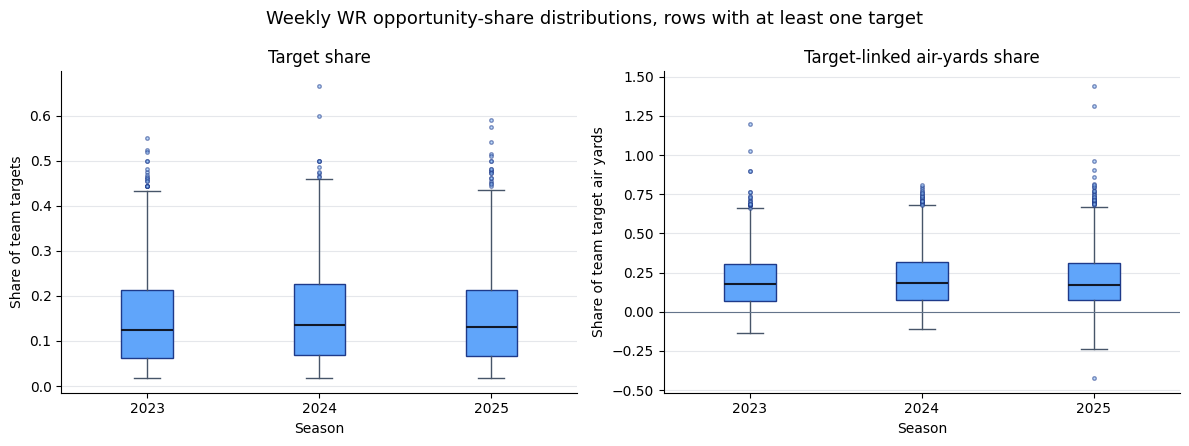

In [17]:
share_plot_population = silver_wr_week.loc[silver_wr_week["pbp_targets"].gt(0)]
season_order = sorted(share_plot_population["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

target_share_values = [
    share_plot_population.loc[
        share_plot_population["season"].eq(season), "target_share"
    ].dropna().astype("float64")
    for season in season_order
]
air_share_values = [
    share_plot_population.loc[
        share_plot_population["season"].eq(season), "target_air_yards_share"
    ].dropna().astype("float64")
    for season in season_order
]

box_style = {
    "patch_artist": True,
    "boxprops": {"facecolor": "#60a5fa", "edgecolor": "#1e3a8a"},
    "medianprops": {"color": "#111827", "linewidth": 1.5},
    "whiskerprops": {"color": "#475569"},
    "capprops": {"color": "#475569"},
    "flierprops": {
        "marker": "o",
        "markersize": 2.5,
        "markerfacecolor": "#93c5fd",
        "markeredgecolor": "#1e3a8a",
        "alpha": 0.55,
    },
}

axes[0].boxplot(target_share_values, tick_labels=season_order, **box_style)
axes[0].set_title("Target share")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Share of team targets")

axes[1].boxplot(air_share_values, tick_labels=season_order, **box_style)
axes[1].axhline(0, color="#64748b", linewidth=0.8)
axes[1].set_title("Target-linked air-yards share")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Share of team target air yards")

for axis in axes:
    axis.grid(axis="y", color="#e5e7eb", linewidth=0.8)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Weekly WR opportunity-share distributions, rows with at least one target",
    fontsize=13,
)
fig.tight_layout()
plt.show()

Target-share distributions remain within zero and one. Target-linked air-yards share has a wider signed range because negative air-yard targets affect both player and team totals; values below zero or above one are therefore valid rather than automatic quality failures.

### 16. Persist season-partitioned Silver Parquet

Each partition is written and immediately reloaded. Shape, columns, dtypes, season membership, and declared grain must survive the round trip.

In [18]:
WR_WEEK_DIR.mkdir(parents=True, exist_ok=True)

output_records = []
for season in SEASONS:
    wr_week_partition = (
        silver_wr_week.loc[silver_wr_week["season"].eq(season)]
        .sort_values(["week", "team", "player_id"])
        .reset_index(drop=True)
    )
    wr_week_path = WR_WEEK_DIR / f"wr_week_{season}.parquet"
    wr_week_partition.to_parquet(wr_week_path, index=False)
    wr_week_reloaded = pd.read_parquet(wr_week_path)

    assert wr_week_reloaded.shape == wr_week_partition.shape
    assert wr_week_reloaded.columns.tolist() == wr_week_partition.columns.tolist()
    assert (
        wr_week_reloaded.dtypes.astype(str).tolist()
        == wr_week_partition.dtypes.astype(str).tolist()
    )
    assert set(wr_week_reloaded["season"].unique()) == {season}
    assert not wr_week_reloaded.duplicated(WR_WEEK_GRAIN).any()

    output_records.append(
        {
            "dataset": "silver_wr_week",
            "season": season,
            "rows": len(wr_week_reloaded),
            "columns": len(wr_week_reloaded.columns),
            "grain": " + ".join(WR_WEEK_GRAIN),
            "duplicate_grain_rows": wr_week_reloaded.duplicated(WR_WEEK_GRAIN).sum(),
            "file_mb": wr_week_path.stat().st_size / 1024**2,
            "round_trip_passed": True,
        }
    )

output_summary = pd.DataFrame(output_records)

assert output_summary["rows"].sum() == len(silver_wr_week)
assert output_summary["duplicate_grain_rows"].eq(0).all()
assert output_summary["round_trip_passed"].all()

output_summary

,dataset,season,rows,columns,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,silver_wr_week,2023,3001,59,player_id + season + week + team,0,0.136248,True
1,silver_wr_week,2024,2934,59,player_id + season + week + team,0,0.134079,True
2,silver_wr_week,2025,2946,59,player_id + season + week + team,0,0.137839,True


In [19]:
print(
    f"Wrote {len(output_summary):,} WR-week files with "
    f"{output_summary['rows'].sum():,} total rows, "
    f"{len(silver_wr_week.columns):,} columns, and "
    f"{output_summary['file_mb'].sum():.2f} MB on disk."
)

Wrote 3 WR-week files with 8,881 total rows, 59 columns, and 0.41 MB on disk.


## Takeaways

- `silver_wr_week` contains 8,881 contextual WR player-weeks at `player_id + season + week + team`, with 3,001 rows in 2023, 2,934 in 2024, and 2,946 in 2025.
- Weekly target, receiving-air-yard, and rush-attempt evidence reconciles exactly with standardized PBP on all 7,823 WR rows that have weekly statistics.
- The table preserves 1,058 snap-only WR rows. Their weekly-stat fields remain null, while complete PBP coverage establishes zero target and rush opportunities.
- Target share reproduces nflverse exactly. `target_air_yards_share` is deliberately distinct from nflverse `air_yards_share` because the former uses target-linked team air yards and the latter uses team passing air yards.
- Red-zone, goal-line, end-zone, and rushing shares retain null when the team denominator is zero. No WR count exceeds its corresponding team total.
- Three 59-column season partitions pass schema, dtype, season, grain, and round-trip checks.
- The next position notebook can reuse this pattern for RB facts while adapting the opportunity concepts rather than copying WR-specific definitions.